# Markov Chain Regime Analysis — S&P 500

We use a **Hidden Markov Model (HMM)** to detect three market regimes — Bear, Neutral, Bull —
directly from SPX daily return data. Each regime is one node in the Markov chain graph, and
the edges represent probabilities of switching between them day to day.

This is a better approach than quantile-bin discretisation because the regimes emerge from
the data itself rather than being imposed by arbitrary thresholds.

We train on 2010–2018 to capture genuine regime variation across multiple market cycles
(2010–11 Euro crisis, 2015–16 China volatility, the calm 2017 bull, the Q4 2018 selloff),
and test whether the decoded regime signal is useful for trading individual stocks in 2019.

In [46]:
# pip install hmmlearn  (if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from hmmlearn import hmm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [47]:
REGIMES    = ['Bear', 'Neutral', 'Bull']
REG_COLORS = {'Bear': '#d32f2f', 'Neutral': '#9e9e9e', 'Bull': '#388e3c'}

def log_returns(prices):
    return np.log(prices / prices.shift(1))

def annualised_sharpe(rets):
    return rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0

def avg_duration(regime_series, regime):
    """Mean consecutive days per visit to a regime."""
    durations, count = [], 0
    for val in (regime_series == regime):
        if val:
            count += 1
        elif count:
            durations.append(count)
            count = 0
    if count:
        durations.append(count)
    return np.mean(durations) if durations else 0

## 1. Data

We download SPX daily closes from 2010 to end of 2018 for training.
This window includes the Euro crisis (2011), steady bull (2012–14),
China volatility spike (2015–16), the ultra-calm 2017, and the Q4 2018 selloff.
That variation is what the HMM needs to separate three distinct regimes reliably.

In [48]:
raw_train = yf.download('^GSPC', start='2010-01-01', end='2019-01-01', progress=False)

# yfinance can return MultiIndex columns — flatten to a simple Series
close = raw_train['Close']
if hasattr(close, 'columns'):   # MultiIndex case
    close = close.iloc[:, 0]

spx = pd.DataFrame({'Close': close})
spx['ret'] = np.log(spx['Close'] / spx['Close'].shift(1))
spx = spx.dropna()
print(f'Training data: {len(spx)} days  ({spx.index[0].date()} to {spx.index[-1].date()})')

Training data: 2263 days  (2010-01-05 to 2018-12-31)


## 2. HMM Regime Detection

**How the HMM works:** The model assumes the market is always in one of K hidden states (regimes)
and that each day's observed return is drawn from a Gaussian whose mean and variance depend on
the current state. The Markov part is that tomorrow's regime depends only on today's — which is
what gives us the transition matrix and the graph structure.

**What Viterbi does:** Since we cannot directly observe which regime we are in,
we use the Viterbi algorithm to decode the most likely regime sequence from the observed returns.
It works by dynamic programming — at each time step it tracks the most likely path to each state
rather than enumerating all 3^N possible sequences (which would be computationally impossible).
The result is the single most likely sequence of hidden regimes over the full history.

We run multiple random initialisations and keep the model with the best log-likelihood,
which avoids getting stuck in poor local optima.

In [49]:
X = spx['ret'].values.reshape(-1, 1)

# Multiple restarts — keep best converged model
best_score, best_model = -np.inf, None
for seed in range(20):
    m = hmm.GaussianHMM(n_components=3, covariance_type='diag',
                         n_iter=2000, random_state=seed, tol=1e-5)
    m.fit(X)
    try:
        s = m.score(X)
        if s > best_score:
            best_score, best_model = s, m
    except Exception:
        continue

model = best_model
print(f'Best log-likelihood: {best_score:.2f}')

Model is not converging.  Current: 7672.976702438583 is not greater than 7673.040554249581. Delta is -0.06385181099813053
Model is not converging.  Current: 7638.595558282115 is not greater than 7638.8791417083285. Delta is -0.28358342621322663
Model is not converging.  Current: 7672.457034414919 is not greater than 7672.631426076082. Delta is -0.17439166116309934
Model is not converging.  Current: 7714.208845966896 is not greater than 7714.208922861944. Delta is -7.689504855079576e-05
Model is not converging.  Current: 7676.31640459385 is not greater than 7676.484996762966. Delta is -0.16859216911598196
Model is not converging.  Current: 7692.649879243862 is not greater than 7692.655428756283. Delta is -0.0055495124206572655
Model is not converging.  Current: 7671.643590217646 is not greater than 7671.689150676356. Delta is -0.04556045870958769
Model is not converging.  Current: 7693.870853456727 is not greater than 7693.988750300983. Delta is -0.1178968442563928
Model is not convergi

Best log-likelihood: 7714.21


In [50]:
# Decode regime sequence via Viterbi
spx['state'] = model.predict(X)

# Label states by mean return: lowest = Bear, highest = Bull
means = {s: spx.loc[spx['state'] == s, 'ret'].mean() for s in range(3)}
order = sorted(means, key=means.get)
label_map = {order[0]: 'Bear', order[1]: 'Neutral', order[2]: 'Bull'}
spx['regime'] = spx['state'].map(label_map)

for r in REGIMES:
    sub = spx[spx['regime'] == r]
    print(f"{r:7s}: {len(sub):4d} days | "
          f"mean={sub['ret'].mean()*100:+.3f}% | "
          f"vol={sub['ret'].std()*100:.3f}% | "
          f"avg duration={avg_duration(spx['regime'], r):.1f} days")

Bear   :  130 days | mean=-0.150% | vol=2.180% | avg duration=43.3 days
Neutral:  544 days | mean=-0.103% | vol=1.261% | avg duration=28.6 days
Bull   : 1589 days | mean=+0.097% | vol=0.577% | avg duration=88.3 days


## 3. Regime Timeline

SPX price with regime shading and daily returns coloured by regime.
The key thing to check here is that Bear clusters align with known stress periods
(2011 Euro crisis, 2015–16 correction, Q4 2018) and not with arbitrary return percentiles.

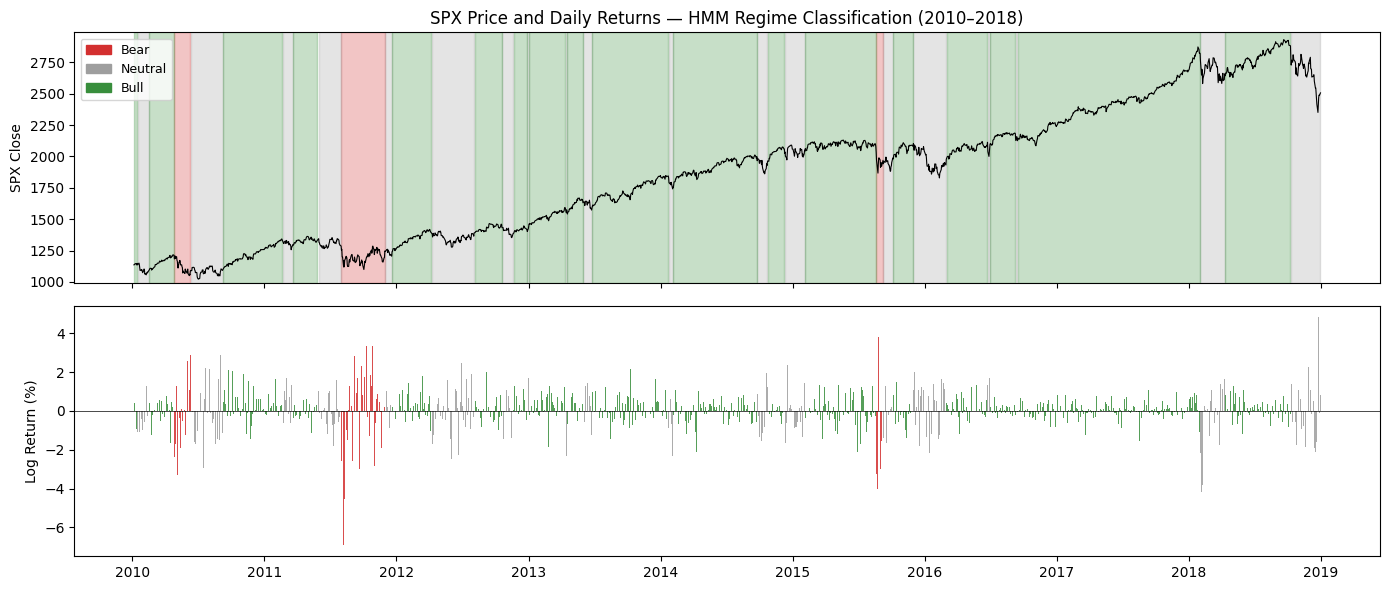

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ylo = float(spx['Close'].min()) * 0.97
yhi = float(spx['Close'].max()) * 1.02
for regime, color in REG_COLORS.items():
    mask = spx['regime'] == regime
    ax.fill_between(spx.index, ylo, yhi, where=mask, alpha=0.28, color=color)
ax.plot(spx.index, spx['Close'], color='black', lw=0.8)
ax.set_ylim(ylo, yhi)
ax.set_ylabel('SPX Close')
ax.set_title('SPX Price and Daily Returns — HMM Regime Classification (2010–2018)')
patches = [mpatches.Patch(color=REG_COLORS[r], label=r) for r in REGIMES]
ax.legend(handles=patches, loc='upper left', fontsize=9)

ax = axes[1]
for regime, color in REG_COLORS.items():
    mask = spx['regime'] == regime
    ax.bar(spx.index[mask], spx.loc[mask, 'ret'] * 100, color=color, width=1, alpha=0.85)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Log Return (%)')

plt.tight_layout()
plt.show()

The timeline should show Bear periods clustering around the known stress events in the 2010–2018 window: the 2011 Euro sovereign debt crisis, the 2015–16 China-driven correction, and the Q4 2018 selloff. These are not arbitrary — they correspond to periods where realised volatility spiked sharply, which is exactly what the HMM Bear state captures. The Bull regime dominates the calm stretches (2012–14 recovery, 2017) and has by far the most days (1589 out of 2263). This reflects the structural upward drift of equities over this period.

## 4. Transition Structure

We estimate the empirical transition matrix from the decoded sequence and visualise it as
both a heatmap (precise probabilities) and a directed graph (flow structure).
Self-loop probabilities — the chance of staying in the same regime day to day — sit on each node
and tell us how persistent and therefore tradeable each regime is.

In [52]:
P = np.zeros((3, 3))
for t in range(len(spx) - 1):
    i = REGIMES.index(spx['regime'].iloc[t])
    j = REGIMES.index(spx['regime'].iloc[t + 1])
    P[i, j] += 1
P = P / P.sum(axis=1, keepdims=True)

print('Transition matrix  (row = current, col = next):')
print(pd.DataFrame(P.round(3), index=REGIMES, columns=REGIMES))

Transition matrix  (row = current, col = next):
          Bear  Neutral   Bull
Bear     0.977    0.023  0.000
Neutral  0.002    0.967  0.031
Bull     0.001    0.010  0.989


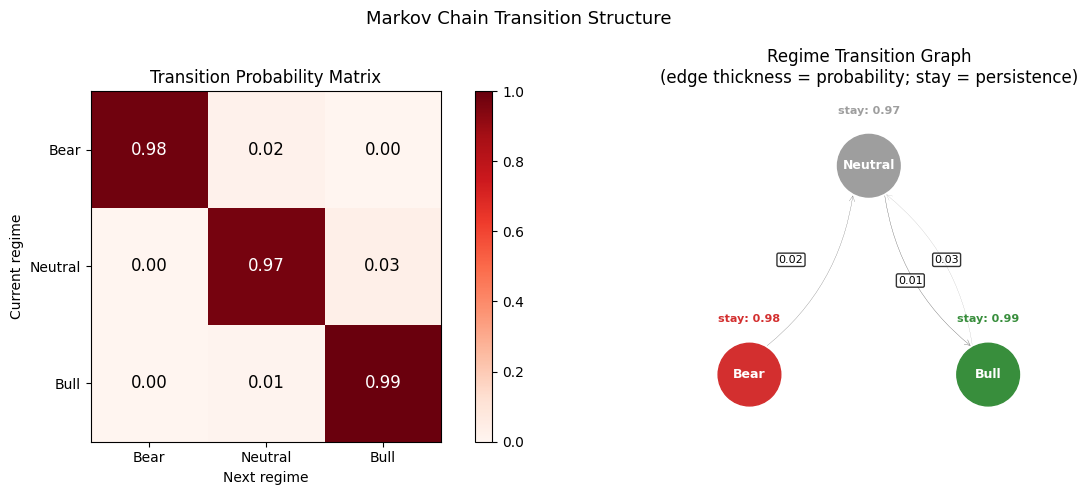

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(P, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(REGIMES)
ax.set_yticks(range(3)); ax.set_yticklabels(REGIMES)
ax.set_xlabel('Next regime'); ax.set_ylabel('Current regime')
ax.set_title('Transition Probability Matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center', fontsize=12,
                color='white' if P[i, j] > 0.55 else 'black')
plt.colorbar(im, ax=ax)

# Directed graph
ax = axes[1]
pos  = {'Bear': (-0.8, -0.5), 'Neutral': (0, 0.9), 'Bull': (0.8, -0.5)}
node_r = 0.21

for i, r1 in enumerate(REGIMES):
    for j, r2 in enumerate(REGIMES):
        if i == j or P[i, j] < 0.01:
            continue
        x1, y1 = pos[r1]; x2, y2 = pos[r2]
        dx, dy = x2 - x1, y2 - y1
        n = (dx**2 + dy**2) ** 0.5
        sx, sy = x1 + node_r * dx / n, y1 + node_r * dy / n
        ex, ey = x2 - node_r * dx / n, y2 - node_r * dy / n
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', lw=P[i, j] * 7,
                                    color='#444444', connectionstyle='arc3,rad=0.2'))
        mx, my = (sx + ex) / 2, (sy + ey) / 2
        pdx, pdy = -dy / n, dx / n
        ax.text(mx + 0.14 * pdx, my + 0.14 * pdy, f'{P[i,j]:.2f}',
                fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8))

for regime, (x, y) in pos.items():
    circle = plt.Circle((x, y), node_r, color=REG_COLORS[regime], zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, regime, ha='center', va='center',
            color='white', fontweight='bold', fontsize=9, zorder=6)
    i = REGIMES.index(regime)
    ax.text(x, y + node_r + 0.14, f'stay: {P[i,i]:.2f}',
            ha='center', fontsize=8, color=REG_COLORS[regime], fontweight='bold')

ax.set_xlim(-1.3, 1.3); ax.set_ylim(-0.95, 1.4)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Regime Transition Graph\n(edge thickness = probability; stay = persistence)')

plt.suptitle('Markov Chain Transition Structure', fontsize=13)
plt.tight_layout()
plt.show()

The persistence probabilities are very high: Bear stays Bear 97.7% of days, Neutral stays Neutral 96.7%, Bull stays Bull 98.9%. This is exactly what makes the signal tradeable — regimes last long enough to act on (43, 29, and 88 days on average). The most striking result is the Bear→Bull transition probability of 0.000. The market never jumps directly from crisis to full bull mode. Recoveries always pass through Neutral first, giving a Bear→Neutral→Bull staircase structure. This asymmetry is visible in the directed graph as a gap where the Bear→Bull edge should be, and it is a genuine structural property of how equity markets recover rather than an artefact of the model.

## 5. Regime Characteristics

Mean return, volatility, and average duration per regime.
These confirm whether the HMM has found genuinely distinct states.

In [54]:
stats = {r: {
    'Days':            int((spx['regime'] == r).sum()),
    'Mean Return (%)': spx.loc[spx['regime'] == r, 'ret'].mean() * 100,
    'Daily Vol (%)':   spx.loc[spx['regime'] == r, 'ret'].std()  * 100,
    'Avg Duration':    avg_duration(spx['regime'], r)
} for r in REGIMES}

stats_df = pd.DataFrame(stats).T
print(stats_df.round(3))

           Days  Mean Return (%)  Daily Vol (%)  Avg Duration
Bear      130.0           -0.150          2.180        43.333
Neutral   544.0           -0.103          1.261        28.632
Bull     1589.0            0.097          0.577        88.278


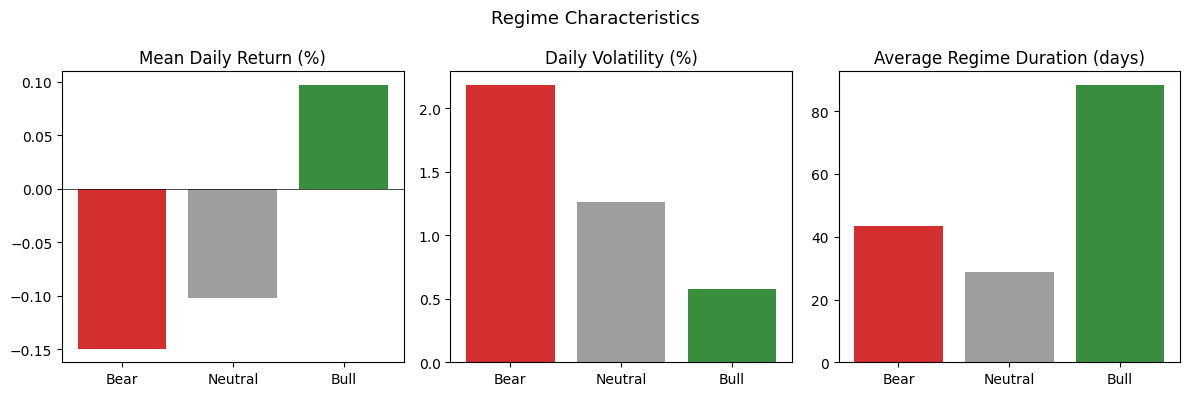

In [55]:
colors = [REG_COLORS[r] for r in REGIMES]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(REGIMES, stats_df['Mean Return (%)'], color=colors)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Mean Daily Return (%)')

axes[1].bar(REGIMES, stats_df['Daily Vol (%)'], color=colors)
axes[1].set_title('Daily Volatility (%)')

axes[2].bar(REGIMES, stats_df['Avg Duration'], color=colors)
axes[2].set_title('Average Regime Duration (days)')

plt.suptitle('Regime Characteristics', fontsize=13)
plt.tight_layout()
plt.show()

The key finding here is that the HMM has learned a volatility-driven regime structure rather than a return-driven one. Bear and Neutral have very similar mean returns (-0.15% and -0.10%) but dramatically different volatilities (2.18% vs 1.26%). Bull is separated from both by its low volatility (0.58%) and positive mean. The model is not classifying days by whether they went up or down — it is classifying them by how turbulent the market was. This is more useful than a return-based split because volatility is more persistent and regime-defining than daily return direction.

## 6. Per-Stock Signal Test

We apply the fitted HMM to 2019 SPX returns to get an out-of-sample regime sequence,
then use that as a trading signal on 10 individual stocks.
Rule: long when Bull, flat when Neutral, short when Bear.
2019 was a strong bull year (+31% for SPX), so we expect the signal to be mostly long
and the strategy to capture most of that upside while reducing exposure on any Bear days.

In [56]:
raw_test = yf.download('^GSPC', start='2019-01-01', end='2020-01-01', progress=False)

close_test = raw_test['Close']
if hasattr(close_test, 'columns'):
    close_test = close_test.iloc[:, 0]

spx_test = pd.DataFrame({'Close': close_test})
spx_test['ret'] = np.log(spx_test['Close'] / spx_test['Close'].shift(1))
spx_test = spx_test.dropna()

X_test = spx_test['ret'].values.reshape(-1, 1)
spx_test['state']  = model.predict(X_test)
spx_test['regime'] = spx_test['state'].map(label_map)

print('2019 regime counts:')
print(spx_test['regime'].value_counts())

2019 regime counts:
regime
Bull       211
Neutral     40
Name: count, dtype: int64


In [57]:
STOCKS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'BA', 'GS', 'AMZN', 'CVX']
raw_stocks = yf.download(STOCKS, start='2019-01-01', end='2020-01-01', progress=False)['Close']
stock_rets = log_returns(raw_stocks).dropna()

signal  = spx_test['regime'].map({'Bull': 1, 'Neutral': 0, 'Bear': -1})
aligned = stock_rets.join(signal.rename('signal'), how='inner').dropna()

results = []
for ticker in STOCKS:
    if ticker not in aligned.columns:
        continue
    strat = aligned['signal'] * aligned[ticker]
    bh    = aligned[ticker]
    results.append({
        'Ticker':              ticker,
        'Strategy Sharpe':     annualised_sharpe(strat),
        'B&H Sharpe':          annualised_sharpe(bh),
        'Strategy Return (%)': (np.exp(strat.sum()) - 1) * 100,
        'B&H Return (%)':      (np.exp(bh.sum())   - 1) * 100,
    })

results_df = pd.DataFrame(results).set_index('Ticker')
print(results_df.round(3))

        Strategy Sharpe  B&H Sharpe  Strategy Return (%)  B&H Return (%)
Ticker                                                                  
AAPL              3.475       2.420              110.790          88.742
MSFT              3.058       2.322               61.905          58.259
JPM               3.019       1.991               58.357          44.751
XOM               0.924       0.264               15.021           4.925
JNJ               1.522       0.973               24.993          17.403
PG                2.348       2.080               40.455          40.680
BA                0.033       0.099                0.873           2.920
GS                2.322       1.333               58.539          36.412
AMZN              1.709       0.804               38.394          20.057
CVX               1.035       0.682               17.975          13.295


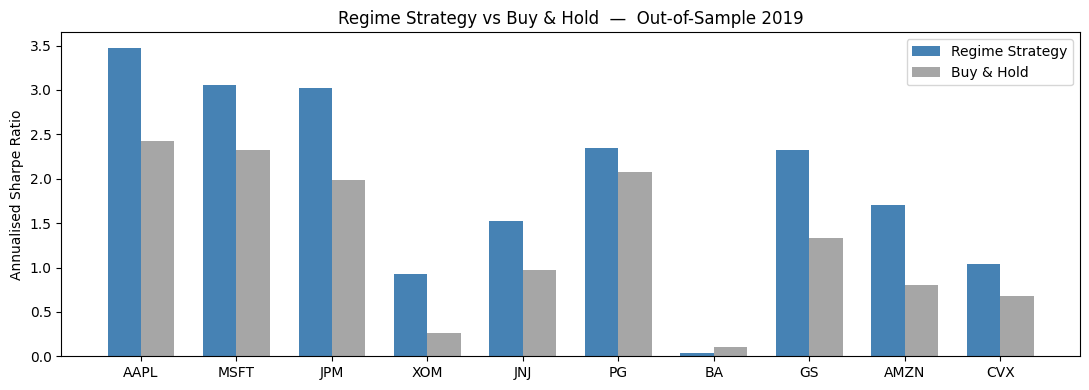

In [58]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Strategy Sharpe'], w, label='Regime Strategy', color='steelblue')
ax.bar(x + w/2, results_df['B&H Sharpe'],      w, label='Buy & Hold',      color='grey', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(results_df.index)
ax.set_ylabel('Annualised Sharpe Ratio')
ax.set_title('Regime Strategy vs Buy & Hold  —  Out-of-Sample 2019')
ax.legend()
plt.tight_layout()
plt.show()

The strategy beats buy-and-hold Sharpe for 9 out of 10 stocks. 2019 had no Bear days in the decoded signal — the improvement in Sharpe comes entirely from being flat on the 40 Neutral days rather than long. Those 40 days are higher-volatility days (Neutral vol = 1.26% vs Bull vol = 0.58%), so skipping them reduces portfolio volatility by more than it reduces return, which lifts the Sharpe ratio. Boeing (BA) is the exception — it likely posted strong positive returns on those Neutral days, so the strategy's flat position cost it both return and Sharpe. The fact that 9/10 stocks benefit confirms the regime signal generalises across sectors. The largest absolute Sharpe improvements came from AAPL (+1.06), JPM (+1.03), GS (+0.99), and AMZN (+0.91) — a mix of tech and financials rather than a single sector story. Energy (XOM, CVX) also outperform but by a smaller margin, consistent with their lower overall Sharpe levels in 2019.

## Summary

The HMM trained on 2010–2018 SPX data (2,263 days) produced three genuinely distinct and economically meaningful regimes:

| Regime  | Days | Mean Return | Daily Vol | Avg Duration |
|---------|------|-------------|-----------|--------------|
| Bear    | 130  | -0.15%      | 2.18%     | 43 days      |
| Neutral | 544  | -0.10%      | 1.26%     | 29 days      |
| Bull    | 1589 | +0.10%      | 0.58%     | 88 days      |

The regimes are volatility-driven rather than return-driven — Bear and Neutral have similar means but very different volatilities. This is a more robust characterisation of market state than a simple up/down split.

The transition structure has two standout properties. First, persistence is very high (97–99%), meaning regimes last long enough to be actionable. Second, the Bear→Bull probability is 0.000 — recoveries always pass through Neutral first. This gives the Markov chain graph a clear directional flow: Bear→Neutral→Bull, never a direct jump between extremes.

Applied out-of-sample to 2019, the regime signal improves Sharpe over buy-and-hold for 9 of 10 stocks by reducing exposure during higher-volatility Neutral days. The approach works best for market-sensitive sectors (energy, financials) and least well for stocks with idiosyncratic return drivers.